[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/02_decision_model_from_scratch.ipynb)

# 2 · Build a tiny decision model from scratch

**Path:** Optional math  
**Before you start:** Basic Python; lesson 01; matrix multiplication is explained here

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Training changes a table of numbers so examples receive better scores. We normalize those scores into probabilities, then choose the largest.

**Your first pass:** Follow sections 1–4 for the main idea. Decision regions and the gradient check are optional deeper work.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Feature** | A number the model uses as an input. |
| **Weight** | A learned number that changes an input’s contribution. |
| **Logit** | A score before it becomes a probability. |
| **Loss** | A penalty for a poor prediction. |

## Goal
Learn the general machinery behind **direct scoring**: features → logits → probabilities → decision.
We will train a three-class linear model using NumPy, so every operation is visible.

**This is not Jev, a replica of Jev, or RLCD.** Our toy is a supervised classifier on synthetic numeric
features. It does not understand text or new question descriptions.

TypeSafe reports a new architecture, parallel sampler, and Reinforcement Learning for Calibrated
Decisions (RLCD). It describes producing decision probabilities in parallel instead of decoding
answer text token by token. The reviewed public pages do not specify the architecture or a reproducible
training recipe. [Announcement](https://typesafe.ai/blog/introducing-system-one-models-and-jev).

## Setup
No GPU, downloaded weights, or API access.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "lab_core.py").is_file()), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if not (COURSE_ROOT / "src" / "lab_core.py").is_file():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

## Begin with numbers you can calculate by hand

Before the matrix notation, follow **one** example. We invent two input features: 2 and 1.
Each option has one weight for each feature and one extra number called a bias.

For the technical option: **2 × 0.8 + 1 × (−0.2) + 0.1 = 1.5**.
Repeat that multiplication-and-addition for the other options. The table below traces every term.
These fixed weights are handmade; the later training experiment learns its own weights.

In [2]:
trace_inputs = np.array([2.0, 1.0])
trace_options = ['technical', 'billing', 'other']
trace_weights = np.array([[0.8, -0.3, 0.1], [-0.2, 0.6, 0.1]])
trace_bias = np.array([0.1, 0.0, -0.1])
trace_logits = trace_inputs @ trace_weights + trace_bias
trace_exp = np.exp(trace_logits - trace_logits.max())
trace_probabilities = trace_exp / trace_exp.sum()

table(['Option', 'Feature 1 contribution', 'Feature 2 contribution', 'Bias', 'Score (logit)', 'Probability'],
      [[name, f'{trace_inputs[0] * trace_weights[0,i]:.2f}',
        f'{trace_inputs[1] * trace_weights[1,i]:.2f}', f'{trace_bias[i]:.2f}',
        f'{trace_logits[i]:.2f}', f'{trace_probabilities[i]:.1%}']
       for i,name in enumerate(trace_options)])
print('Most likely option:', trace_options[trace_probabilities.argmax()])

Option,Feature 1 contribution,Feature 2 contribution,Bias,Score (logit),Probability
technical,1.60,-0.20,0.10,1.50,66.9%
billing,-0.60,0.60,0.00,0.00,14.9%
other,0.20,0.10,-0.10,0.20,18.2%


Most likely option: technical


**Read the result:** technical has the largest score and probability. The scores themselves
do not sum to 1; softmax converts them into probabilities that do. The `@` symbol performs the
same multiplication-and-addition for every option in one matrix operation.

**Predict a change:** change the technical bias from 0.1 to −2.0. Which option should win?
The technical score becomes −0.6; the other scores stay 0.0 and 0.2, so `other` wins.
Restart and Run All after trying it. This warm-up has its own variables and does not alter the later model.

## Steps
### 1. Make a visible learning problem
Each point has two invented features and one of three classes. We generate independent training
and test examples from the same known process. Classes overlap, so perfect classification is not expected.
These coordinates are a teaching stand-in for a learned representation, not a proposed Jev encoding.

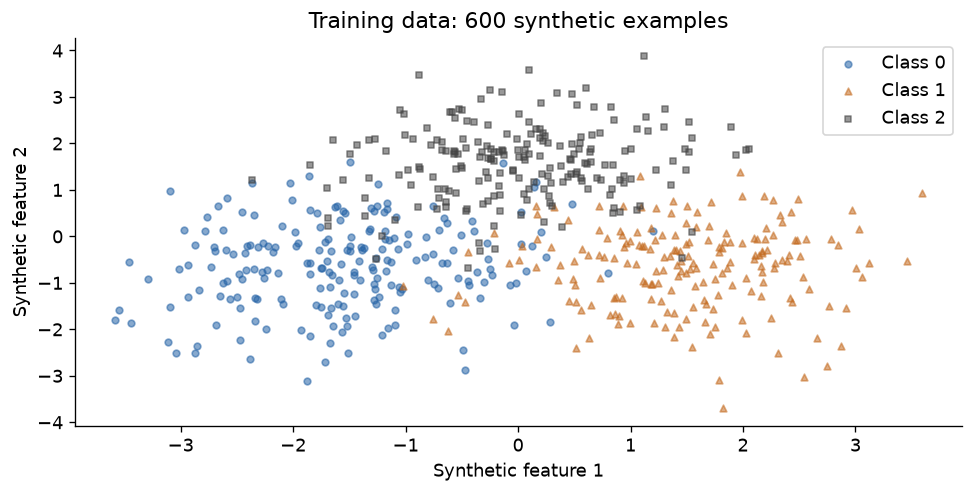

In [3]:
rng = np.random.default_rng(42)
centers = np.array([[-1.5, -0.6], [1.5, -0.6], [0, 1.5]])

def sample(n):
    labels = rng.integers(0, 3, n)
    features = centers[labels] + rng.normal(0, 0.85, (n, 2))
    return features, labels

X_train, y_train = sample(600)
X_test, y_test = sample(600)
fig, ax = plt.subplots()
for k, (color, marker) in enumerate(zip([BLUE, ORANGE, GREY], ['o', '^', 's'])):
    mask = y_train == k
    ax.scatter(*X_train[mask].T, s=16, alpha=0.55, color=color, marker=marker, label=f'Class {k}')
ax.set(xlabel='Synthetic feature 1', ylabel='Synthetic feature 2', title='Training data: 600 synthetic examples')
ax.legend()
show_figure('02_training_data')

### 2. Convert logits into probabilities
A **logit** is an unconstrained score. For a feature vector $x$, our model computes
$z=xW+b$. Softmax turns the three scores into a distribution:
$$p_k=\frac{\exp(z_k/T)}{\sum_j\exp(z_j/T)}.$$
The temperature $T>0$ controls concentration. Lower temperature makes the distribution sharper;
it does not make the answers more correct. Subtracting the maximum logit prevents overflow without
changing the answer. This is general classifier mathematics, not a disclosed Jev formula.

In [4]:
def softmax(logits, temperature=1.0):
    if temperature <= 0:
        raise ValueError('Temperature must be positive')
    scaled = logits / temperature
    shifted = scaled - scaled.max(axis=-1, keepdims=True)
    values = np.exp(shifted)
    return values / values.sum(axis=-1, keepdims=True)

table(['Temperature', 'Class probabilities'],
      [(t, np.round(softmax(np.array([0.2, 1.4, -0.3]), t), 3)) for t in [0.5, 1, 2]])

Temperature,Class probabilities
0.5,[0.081 0.89 0.03 ]
1,[0.203 0.674 0.123]
2,[0.278 0.506 0.216]


### 3. Train by penalizing the wrong distribution
Cross-entropy loss is $-\frac{1}{N}\sum_i\log p_{i,y_i}$. It penalizes assigning low probability
to the correct class. For this linear-softmax model the gradient of the logits is $(p-Y)/N$,
where $Y$ contains one-hot labels. We take small steps opposite the gradient.

This ordinary supervised objective teaches probabilistic prediction. It is **not** an implementation
of RLCD; TypeSafe describes RLCD's objective at a high level as calibrated decisions.
[AI primer](https://docs.typesafe.ai/introduction/machine-learning-primer).

Test accuracy on this synthetic problem: 88.5%


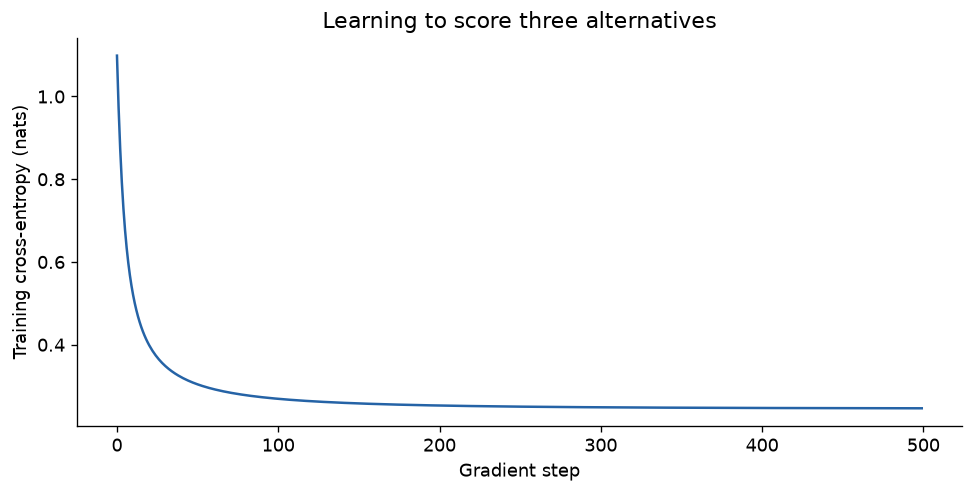

In [5]:
weights = np.zeros((2, 3))
bias = np.zeros(3)
targets = np.eye(3)[y_train]
losses = []
for step in range(500):
    p = softmax(X_train @ weights + bias)
    losses.append(-np.log(p[np.arange(len(y_train)), y_train].clip(1e-12, 1)).mean())
    gradient = (p - targets) / len(y_train)
    weights -= 0.15 * X_train.T @ gradient
    bias -= 0.15 * gradient.sum(axis=0)

test_probabilities = softmax(X_test @ weights + bias)
accuracy = (test_probabilities.argmax(axis=1) == y_test).mean()
print(f'Test accuracy on this synthetic problem: {accuracy:.1%}')
fig, ax = plt.subplots()
ax.plot(losses, color=BLUE)
ax.set(xlabel='Gradient step', ylabel='Training cross-entropy (nats)', title='Learning to score three alternatives')
show_figure('02_training_loss')

### 4. Inspect one forward pass
All three option scores are computed by one matrix operation. A new input still needs inference,
but this toy does not run a loop to generate an answer string.

In [6]:
example = np.array([[1.0, -0.5]])
logits = example @ weights + bias
probabilities = softmax(logits)[0]
table(['Class', 'Logit', 'Probability'],
      [(k, f'{logits[0, k]:.3f}', f'{p:.3f}') for k, p in enumerate(probabilities)])
print('Predicted class:', int(probabilities.argmax()))

Class,Logit,Probability
0,-1.099,0.030
1,2.361,0.945
2,-1.261,0.025


Predicted class: 1


### 5. Why skipping output-token decoding can help
A simplified latency model is:
$$t_{\text{text}}=t_{\text{input}}+L\,t_{\text{token}},\qquad
t_{\text{decision}}=t_{\text{input}}+t_{\text{head}}.$$
$L$ is generated output length. This only illustrates a possible source of savings.
Real latency also depends on hardware, input length, batching, architecture, and network overhead.
The next chart uses **invented constants**, not measured Jev or LLM performance.

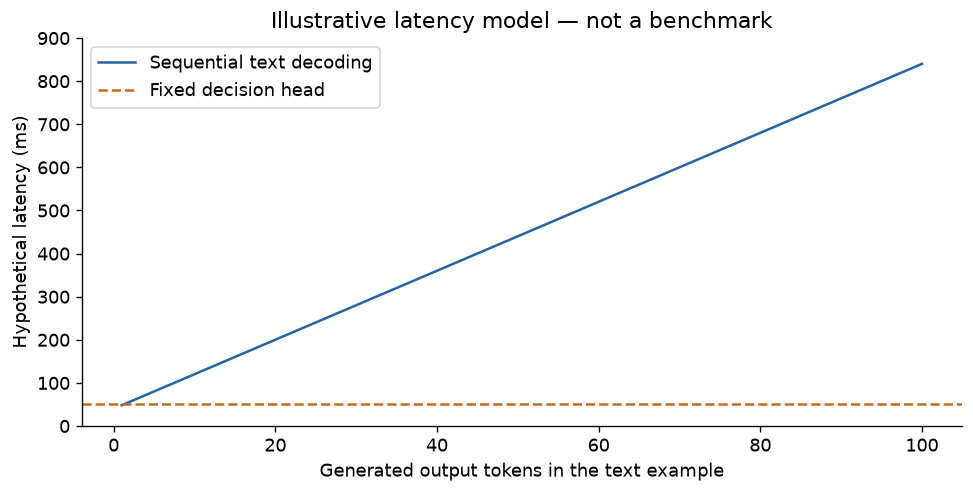

In [7]:
output_tokens = np.arange(1, 101)
input_ms, token_ms, decision_ms = 40, 8, 12  # Assumed, for illustration only.
fig, ax = plt.subplots()
ax.plot(output_tokens, input_ms + output_tokens * token_ms, color=BLUE, label='Sequential text decoding')
ax.axhline(input_ms + decision_ms, color=ORANGE, linestyle='--', label='Fixed decision head')
ax.set(xlabel='Generated output tokens in the text example', ylabel='Hypothetical latency (ms)',
       title='Illustrative latency model — not a benchmark', ylim=(0, 900))
ax.legend()
show_figure('02_latency_illustration')

> **Optional deeper practice.** You can stop reading here on your first pass. If you run the notebook, use Run All so the later checks still have their inputs.

### 6. Keep track of the tensor dimensions
Our training matrix $X$ has one row per example. Multiplying by $W$ produces one score per class.
Bias adds one learned offset to each class, repeated across rows by NumPy broadcasting.

In [8]:
table(['Tensor', 'Shape', 'Meaning'], [
    ('X_train', X_train.shape, '600 examples × 2 features'),
    ('weights', weights.shape, '2 features × 3 classes'),
    ('bias', bias.shape, 'one offset per class'),
    ('logits', (X_train @ weights + bias).shape, '600 examples × 3 class scores'),
])

Tensor,Shape,Meaning
X_train,"(600, 2)",600 examples × 2 features
weights,"(2, 3)",2 features × 3 classes
bias,"(3,)",one offset per class
logits,"(600, 3)",600 examples × 3 class scores


### 7. See what the classifier learned
Background colors mark the most likely class; dashed contours show the maximum class probability.
Each panel comes from the same trained model. The numeric features are meaningful only inside
this synthetic world. Far from the training clouds, a linear classifier can still be extremely confident.
That is an important limitation: low uncertainty is not an out-of-distribution detector.

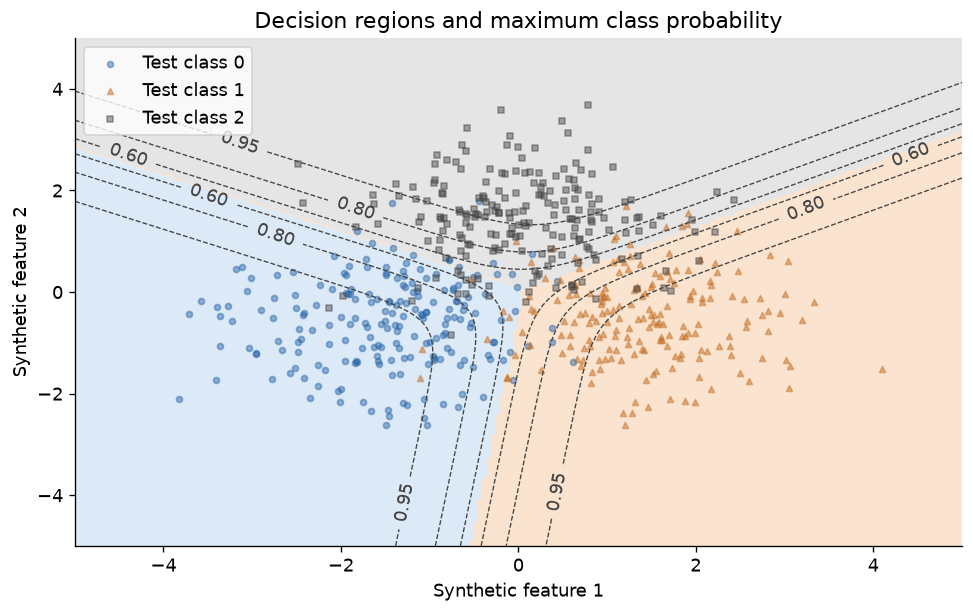

Probabilities far outside the training cloud: [[0. 1. 0.]]


In [9]:
from matplotlib.colors import ListedColormap
gx, gy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid = np.column_stack([gx.ravel(), gy.ravel()])
grid_prob = softmax(grid @ weights + bias)
fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(gx, gy, grid_prob.argmax(axis=1).reshape(gx.shape),
            levels=[-0.5, 0.5, 1.5, 2.5], cmap=ListedColormap(['#dce9f7', '#fae4d0', '#e5e5e5']))
contours = ax.contour(gx, gy, grid_prob.max(axis=1).reshape(gx.shape),
                      levels=[0.6, 0.8, 0.95], colors=GREY, linestyles='--', linewidths=0.8)
ax.clabel(contours, fmt='%.2f')
for k, (color, marker) in enumerate(zip([BLUE, ORANGE, GREY], ['o', '^', 's'])):
    points = X_test[y_test == k]
    ax.scatter(*points.T, s=13, alpha=.45, color=color, marker=marker, label=f'Test class {k}')
ax.set(xlabel='Synthetic feature 1', ylabel='Synthetic feature 2', title='Decision regions and maximum class probability')
ax.legend(loc='upper left')
show_figure('02_decision_regions')
far_away = np.array([[20., -10.]])
print('Probabilities far outside the training cloud:', softmax(far_away @ weights + bias).round(4))

### 8. Verify one gradient by finite differences
For one weight, perturb it slightly in both directions and estimate the slope of the loss.
This is an independent numerical check of the analytic update used above, not a second copy of its formula.

In [10]:
def loss_for(W):
    pp = softmax(X_train @ W + bias)
    return -np.log(pp[np.arange(len(y_train)), y_train]).mean()

epsilon = 1e-5
plus, minus = weights.copy(), weights.copy()
plus[0, 0] += epsilon
minus[0, 0] -= epsilon
numeric_gradient = (loss_for(plus) - loss_for(minus)) / (2 * epsilon)
analytic_gradient = (X_train.T @ (softmax(X_train @ weights + bias) - targets) / len(y_train))[0, 0]
print(f'Numerical: {numeric_gradient:.8f}; analytic: {analytic_gradient:.8f}')
assert np.isclose(numeric_gradient, analytic_gradient, atol=1e-7)

Numerical: 0.00185755; analytic: 0.00185755


**Predict first — exercise 2:** Add 100 to every logit in a row. Do the probabilities change?
Then multiply all logits by 3. Does the most likely class change? Do the probabilities change?
Use the [optional playground setup](../docs/SETUP.md) to test your predictions.

**Connection to Jev:** this model learns a fixed three-column head. A service that accepts new
natural-language criteria needs a way to condition the judgment on those criteria. Notebook 6
explores that distinction and shows a generic attention mechanism without claiming Jev uses it.

## Checks
The loss should fall, rows should sum to 1, and test accuracy should beat the roughly one-third
chance baseline on this deliberately easy synthetic task. None of these checks establishes calibration.

In [11]:
assert losses[-1] < losses[0]
assert np.allclose(test_probabilities.sum(axis=1), 1)
assert np.isfinite(test_probabilities).all()
assert accuracy > 0.65
print(f'Loss: {losses[0]:.3f} → {losses[-1]:.3f}; checks passed.')

Loss: 1.099 → 0.246; checks passed.


## Next Steps
Increase noise from 0.85 to 1.5 and rerun. Why is certainty harder when the classes overlap?
Try multiplying all test logits by 3: the predicted classes stay the same, but probabilities change.
That is why accuracy alone is insufficient. Continue to [calibration](03_calibration_and_decisions.ipynb).

## Take three ideas with you

- A matrix of weights maps features to scores. Softmax converts scores to a distribution.
- Learning changes the weights to reduce loss.
- A confident prediction can still be wrong or outside the training distribution.

**You are ready to move on when:** You can trace features → scores → probabilities → choice without claiming that this toy is Jev.

## Check your understanding

If I make probabilities more extreme, have I made the model more accurate?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>Not necessarily. Multiplying all logits by a positive constant keeps the winning class unchanged. It can change probability quality without changing classification accuracy.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)